In [1]:
from pathlib import Path

import pandas as pd

import jax
import jax.numpy as jnp
import jax.tree_util as jtu

# jax.config.update("jax_enable_x64", True)

from DiffFlowTransport.utils.plot import plot_timeseries_obs_1to1, plot_PQET_quantile
from DiffFlowTransport.utils.plot import plot_PQET_ST, plot_PQET_ST2, plot_PQET_ST3, plot_young_water
from DiffFlowTransport.utils.plot import plot_timeseries, plot_J_Q, plot_timeseries_obs_sim
from DiffFlowTransport.model import load_model

import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
# %reload_ext autoreload
    

# Load model

In [2]:
# model_name = 'mdn-couplingtype0'
model_name = 'mdn-couplingtype3'
# model_name = 'mdn-gaussian-couplingtype4'
# model_name = 'mdn-one_gamma-couplingtype3'
saved_folder = Path("./models-withDiffusion")

f_configs = f'configs-{model_name}.json'


In [3]:
model, loss, flow_dl, transport_data, configs = load_model(f_configs, saved_folder)


INFO:2025-03-20 20:58:39,890:jax._src.xla_bridge:945: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-03-20 20:58:39,890 - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-03-20 20:58:39,895:jax._src.xla_bridge:945: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2025-03-20 20:58:39,895 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


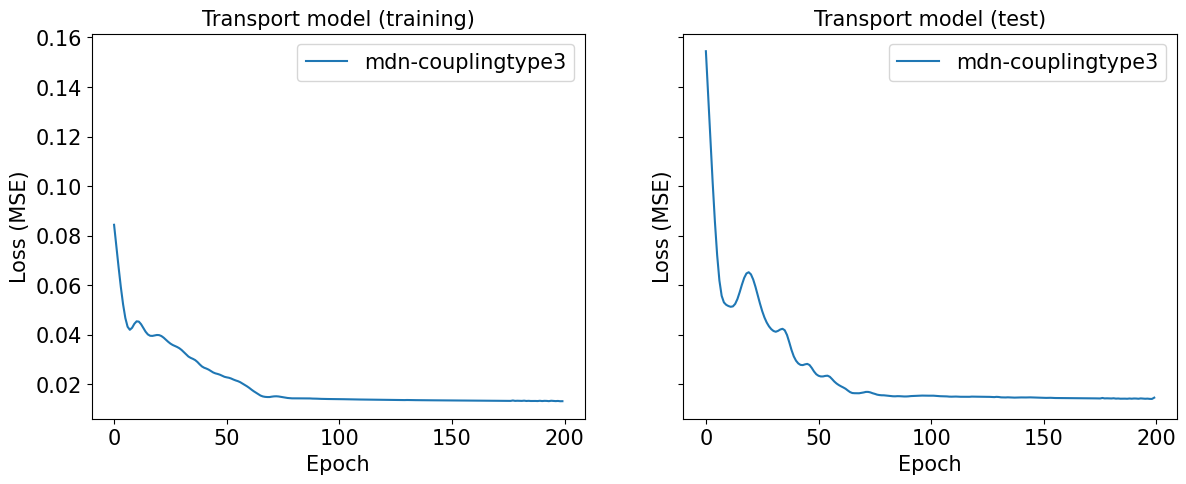

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)
axes[0].plot(loss['transport_loss']['train'], label=model_name)
axes[1].plot(loss['transport_loss']['test'], label=model_name)

for i,ax in enumerate(axes):
    ax.set(xlabel='Epoch', ylabel='Loss (MSE)', 
           title='Transport model (training)' if i==0 else 'Transport model (test)')
    ax.legend()


# Run the model

In [5]:
# Run the models
J, Q, ET, C_J, C_Q, time = transport_data
transport_output, _ = model.run_transport(J, C_J, ET, Q, dl=flow_dl)
transport_output_noQ, flow_output = model.run_transport(J, C_J, ET, Q=None, dl=flow_dl)


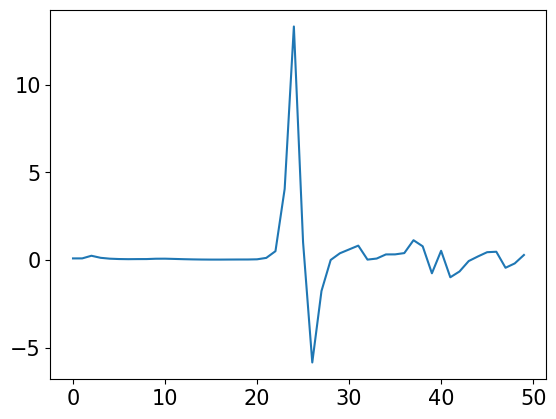

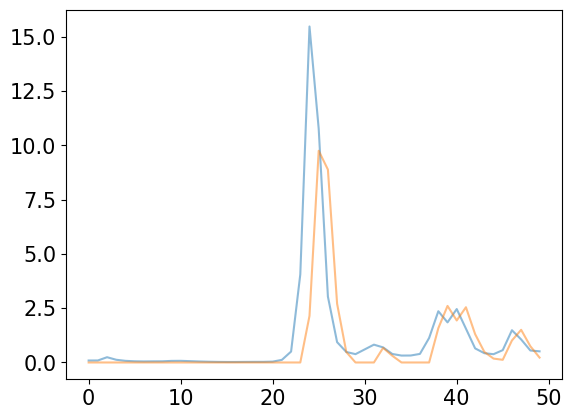

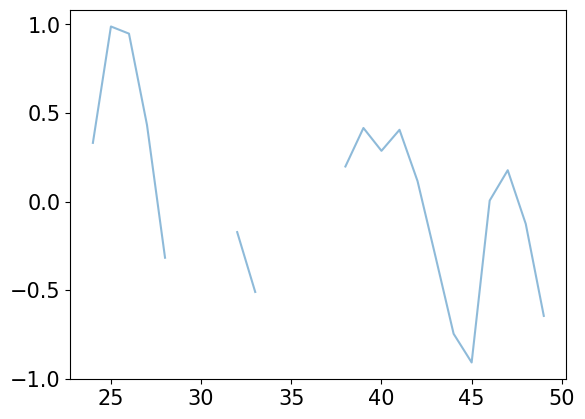

In [6]:
plt.plot(Q[-50:] - flow_output[-50:])
plt.figure()
plt.plot(Q[-50:], alpha=0.5)
plt.plot(flow_output[-50:], alpha=0.5)
plt.figure()
plt.plot(jnp.log10(flow_output[-50:]), alpha=0.5)


In [7]:
# Get the MDN weights
mdn_w = model.get_mdn_weights(Q=Q, ET=ET, dl=flow_dl)
mdn_w_noQ = model.get_mdn_weights(ET=ET, dl=flow_dl)


In [8]:
sT, mT, mQETs, pQETs, mRs, C_Q_pred = transport_output
C_Q_pred2 = transport_output_noQ[-1]
Q_pred = flow_output
data = list(zip(J, Q, Q_pred.flatten(), ET, C_J.flatten(), 
                C_Q.flatten(), C_Q_pred.flatten(), C_Q_pred2.flatten()))
df = pd.DataFrame(data, columns=['J', 'Q', 'Q_simb', 'ET', 'C_J', 'C_Q', 'C_Q_sim', 'C_Q_simb']).astype(float)
df.index = time


# Post-analysis

In [9]:
train_s, train_e = configs['train_configs']['train_start'], configs['train_configs']['train_end']
test_s, test_e = configs['train_configs']['test_start'], configs['train_configs']['test_end']
dt = configs['transport_configs']['transport_specs']['dt']


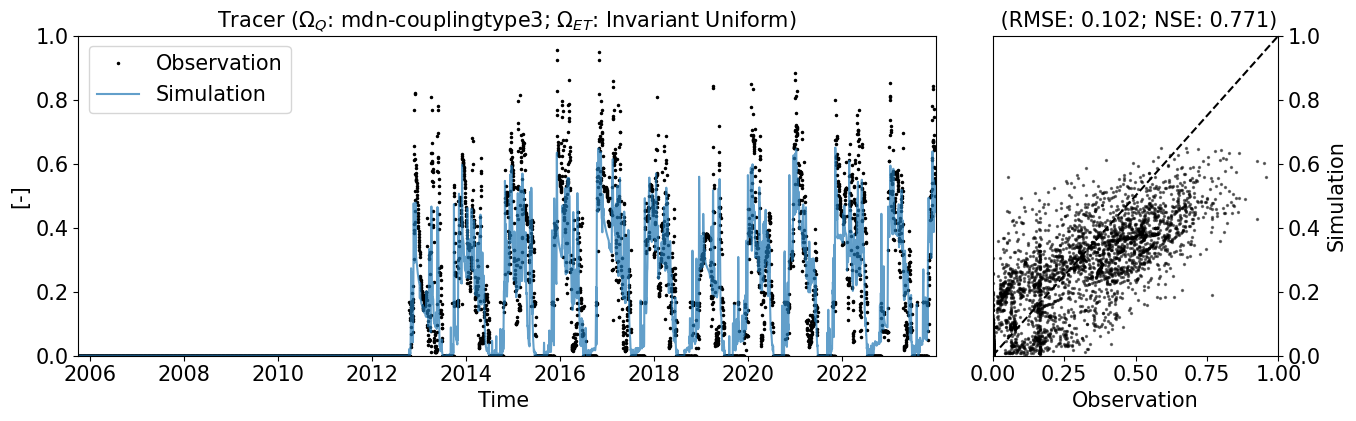

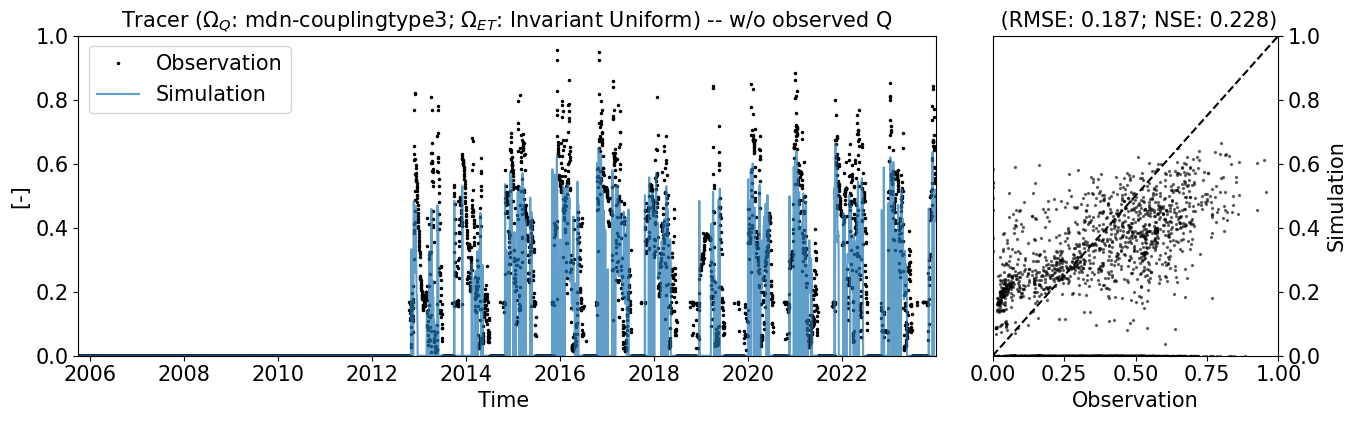

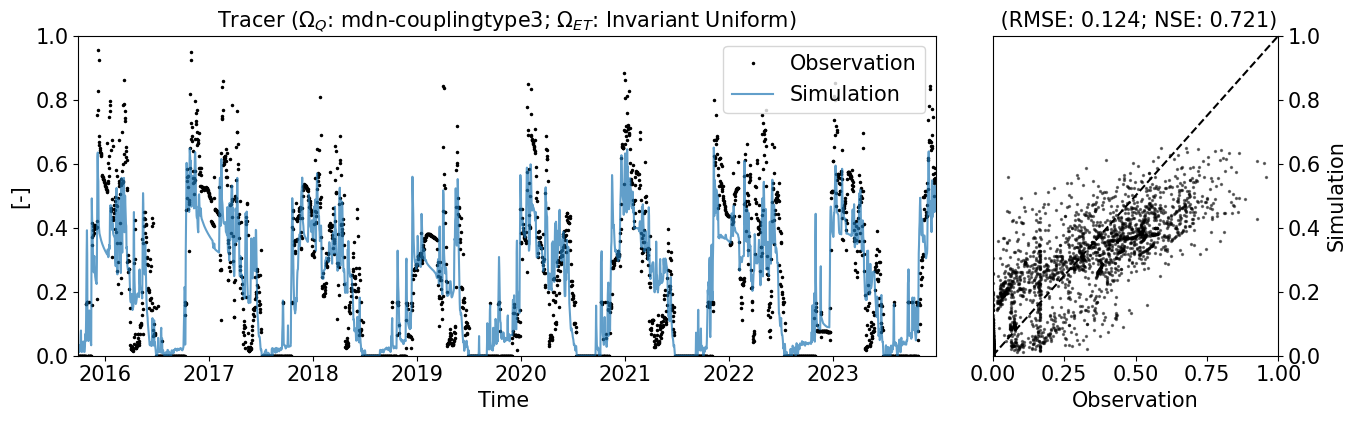

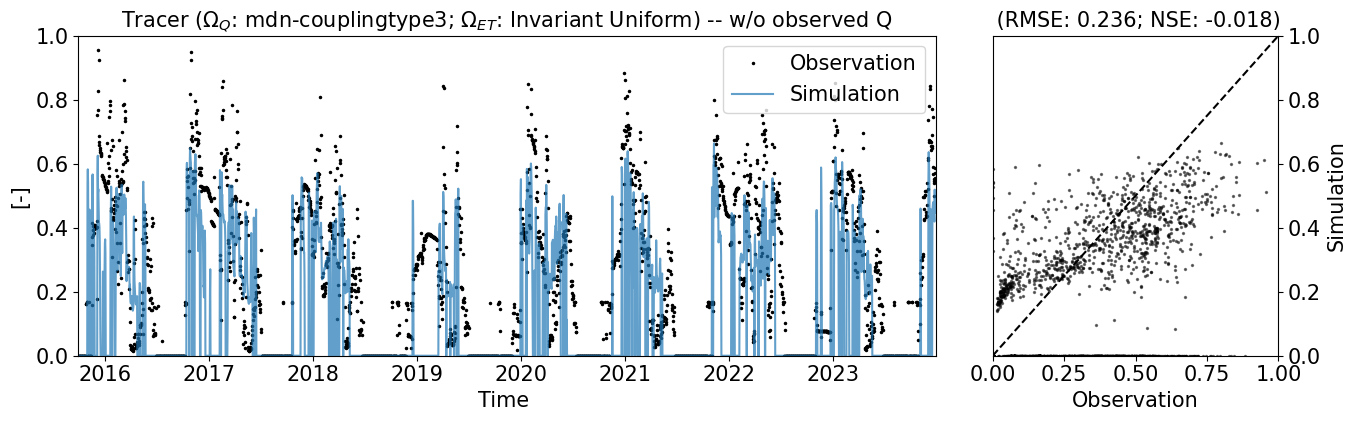

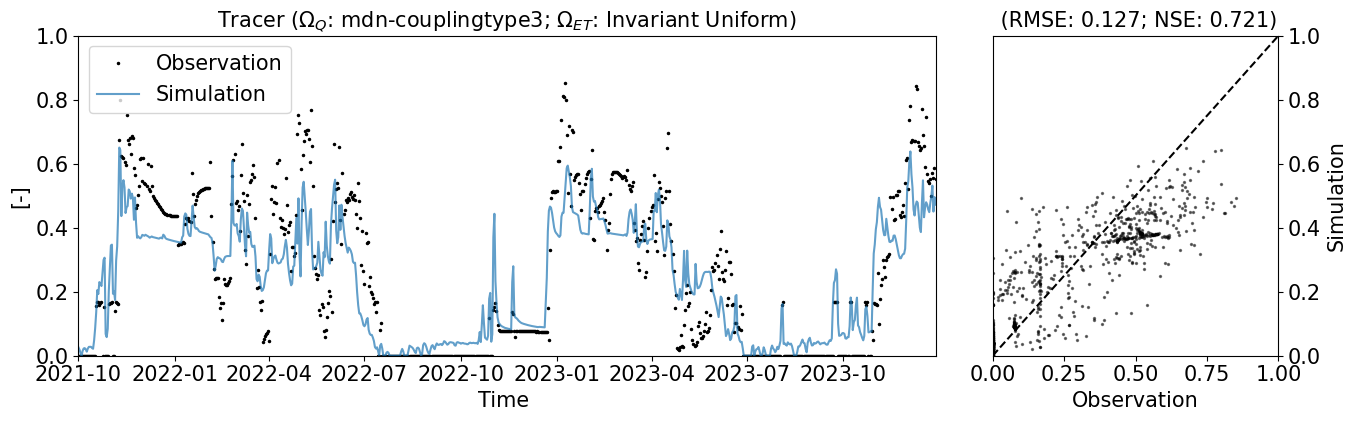

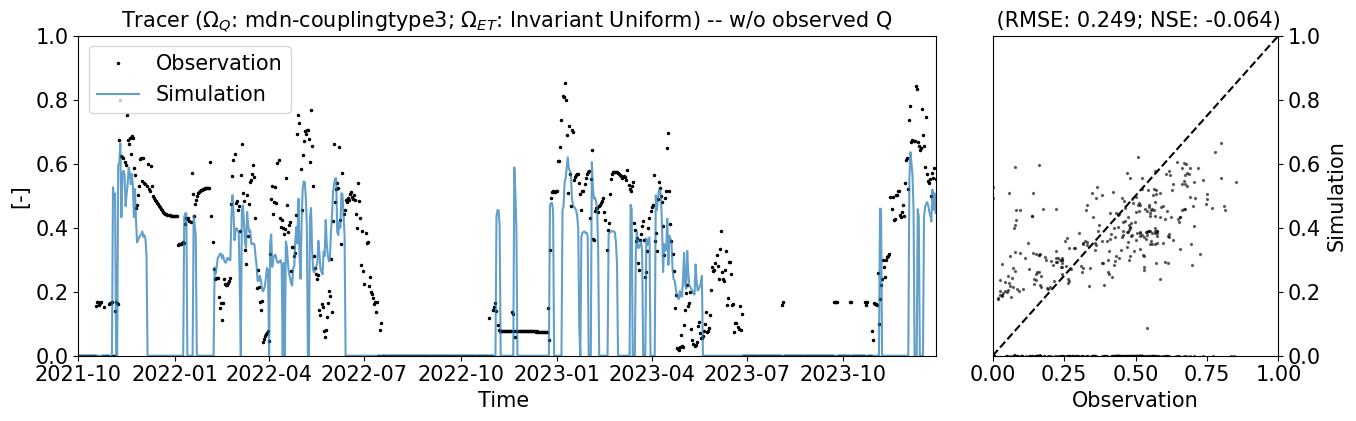

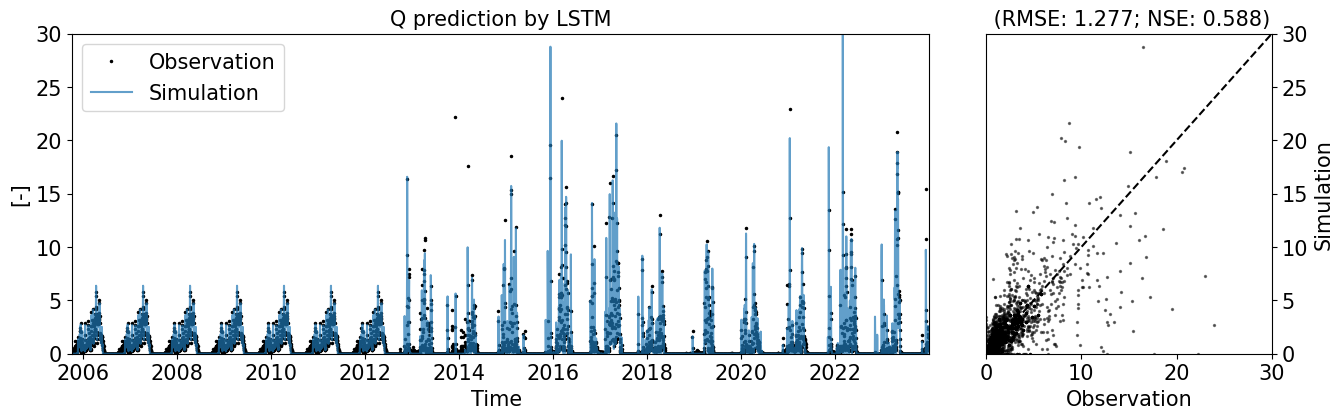

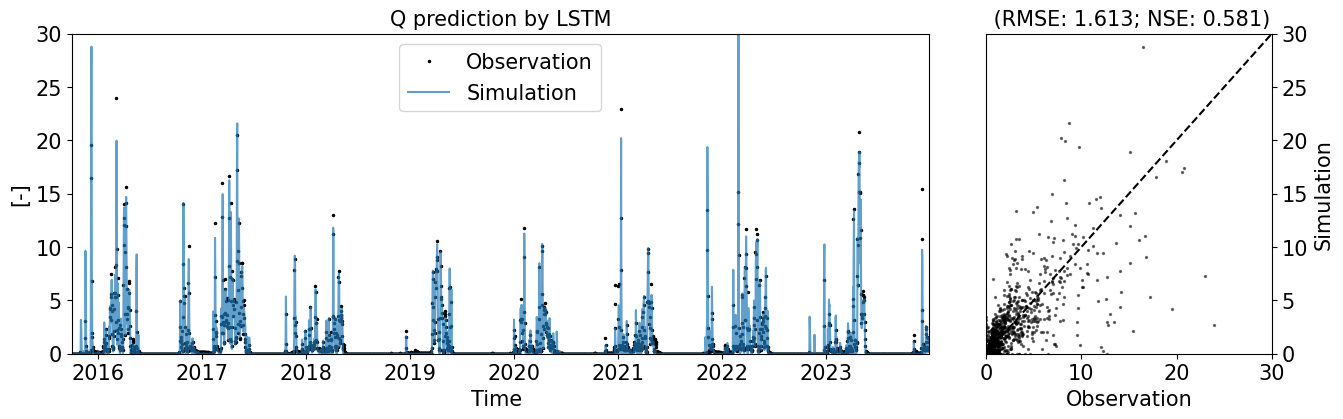

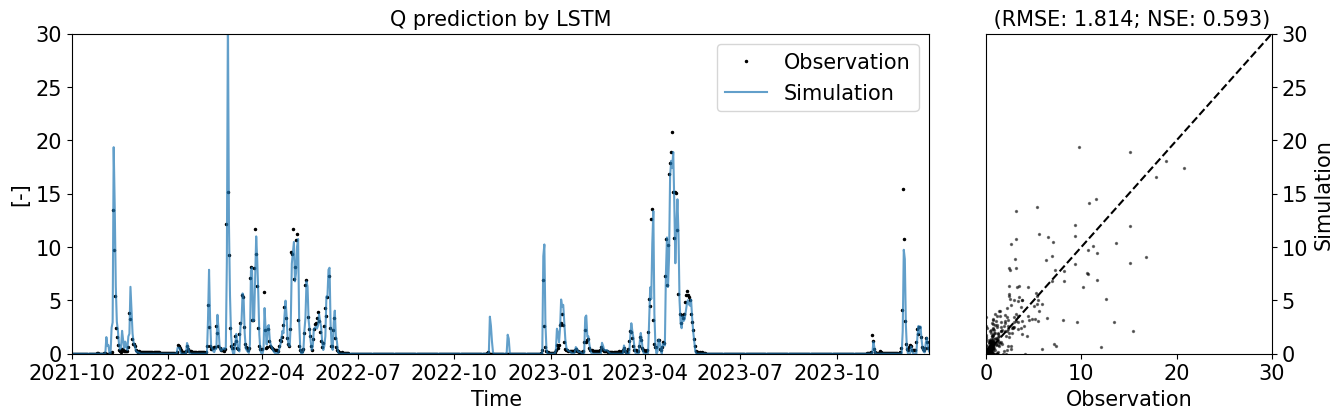

In [10]:
# Plot the C_J simulation
plot_timeseries_obs_1to1(
    obs=df['C_Q'].values, sim=df['C_Q_sim'].values, lim=[0,1], timesteps=df.index,
    varn=f'Tracer ($\Omega_Q$: {model_name}; ' + '$\Omega_{ET}$: Invariant Uniform)'
);
plot_timeseries_obs_1to1(
    obs=df['C_Q'].values, sim=df['C_Q_simb'].values, lim=[0,1], timesteps=df.index,
    varn=f'Tracer ($\Omega_Q$: {model_name}; ' + '$\Omega_{ET}$: Invariant Uniform) -- w/o observed Q'
);
# Plot the C_J simulation -- training + test
plot_timeseries_obs_1to1(
    obs=df[train_s:test_e]['C_Q'].values, sim=df[train_s:test_e]['C_Q_sim'].values, lim=[0,1], timesteps=df[train_s:test_e].index,
    varn=f'Tracer ($\Omega_Q$: {model_name}; ' + '$\Omega_{ET}$: Invariant Uniform)'
);
plot_timeseries_obs_1to1(
    obs=df[train_s:test_e]['C_Q'].values, sim=df[train_s:test_e]['C_Q_simb'].values, lim=[0,1], timesteps=df[train_s:test_e].index,
    varn=f'Tracer ($\Omega_Q$: {model_name}; ' + '$\Omega_{ET}$: Invariant Uniform) -- w/o observed Q'
);
# Plot the C_J simulation -- test
plot_timeseries_obs_1to1(
    obs=df[test_s:test_e]['C_Q'].values, sim=df[test_s:test_e]['C_Q_sim'].values, lim=[0,1], timesteps=df[test_s:test_e].index,
    varn=f'Tracer ($\Omega_Q$: {model_name}; ' + '$\Omega_{ET}$: Invariant Uniform)'
);
plot_timeseries_obs_1to1(
    obs=df[test_s:test_e]['C_Q'].values, sim=df[test_s:test_e]['C_Q_simb'].values, lim=[0,1], timesteps=df[test_s:test_e].index,
    varn=f'Tracer ($\Omega_Q$: {model_name}; ' + '$\Omega_{ET}$: Invariant Uniform) -- w/o observed Q'
);
# Streamflow
plot_timeseries_obs_1to1(
    obs=df['Q'].values, sim=df['Q_simb'].values, lim=[0,30], timesteps=df.index,
    varn='Q prediction by LSTM'
);
plot_timeseries_obs_1to1(
    obs=df[train_s:test_e]['Q'].values, sim=df[train_s:test_e]['Q_simb'].values, lim=[0,30], timesteps=df[train_s:test_e].index,
    varn='Q prediction by LSTM'
);
plot_timeseries_obs_1to1(
    obs=df[test_s:test_e]['Q'].values, sim=df[test_s:test_e]['Q_simb'].values, lim=[0,30], timesteps=df[test_s:test_e].index,
    varn='Q prediction by LSTM'
);


(Array([0.5688384 , 0.00917076, 0.4219909 ], dtype=float32),
 Array([0.62846   , 0.00836083, 0.3631791 ], dtype=float32))

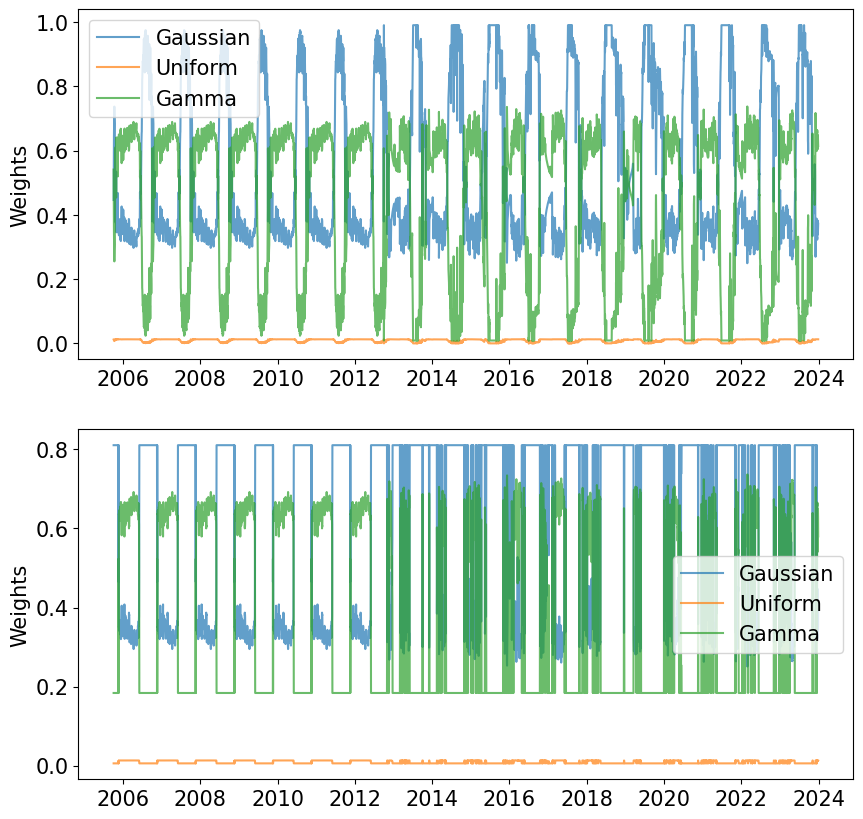

In [12]:
# MDN weights
distributions = ['Gaussian', 'Uniform', 'Gamma']
fig, axes = plt.subplots(2, 1, figsize=(10,10))
for i,dist in enumerate(distributions):
    axes[0].plot(time, mdn_w[:,i], alpha=0.7, label=dist)
    axes[1].plot(time, mdn_w_noQ[:,i], alpha=0.7, label=dist)
for ax in axes:
    ax.set(ylabel='Weights')
    ax.legend()
mdn_w.mean(axis=0), mdn_w_noQ.mean(axis=0)


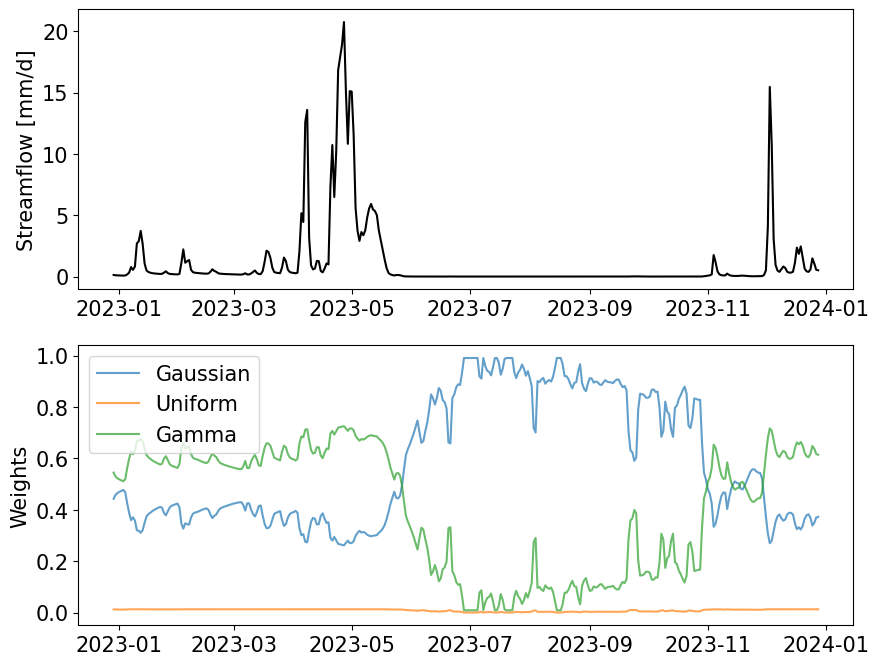

In [13]:
# MDN weights -- zoom in
distributions = ['Gaussian', 'Uniform', 'Gamma']
fig, axes = plt.subplots(2, 1, figsize=(10,8))
axes[0].plot(time[-365:], Q[-365:], 'k', label=dist)
# axes[0].plot(time[-365:], Q_pred[-365:], 'k--', label=dist)
for i,dist in enumerate(distributions):
    axes[1].plot(time[-365:], mdn_w[-365:,i], alpha=0.7, label=dist)
axes[0].set(ylabel='Streamflow [mm/d]')
axes[1].set(ylabel='Weights')
axes[1].legend()


array([<Axes: title={'center': 'Q age distribution ()'}, ylabel='Age [Days]'>,
       <Axes: title={'center': 'ET age distribution ()'}, ylabel='Age [Days]'>],
      dtype=object)

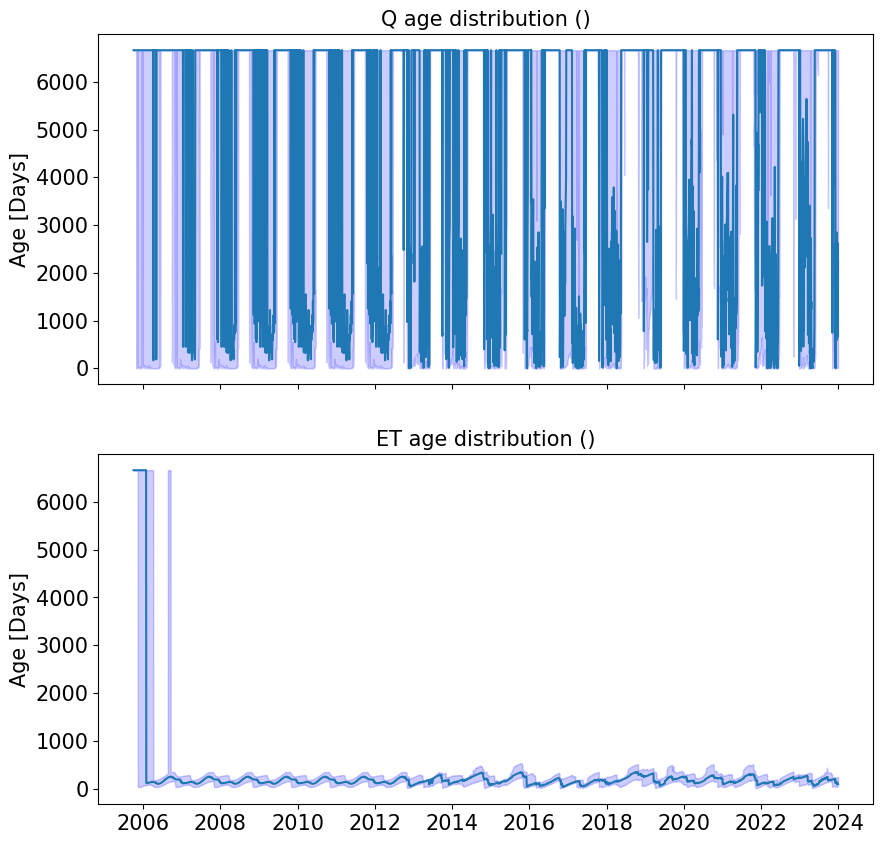

In [14]:
# Plot the age distribution
plot_PQET_quantile(pQETs, dt, time)


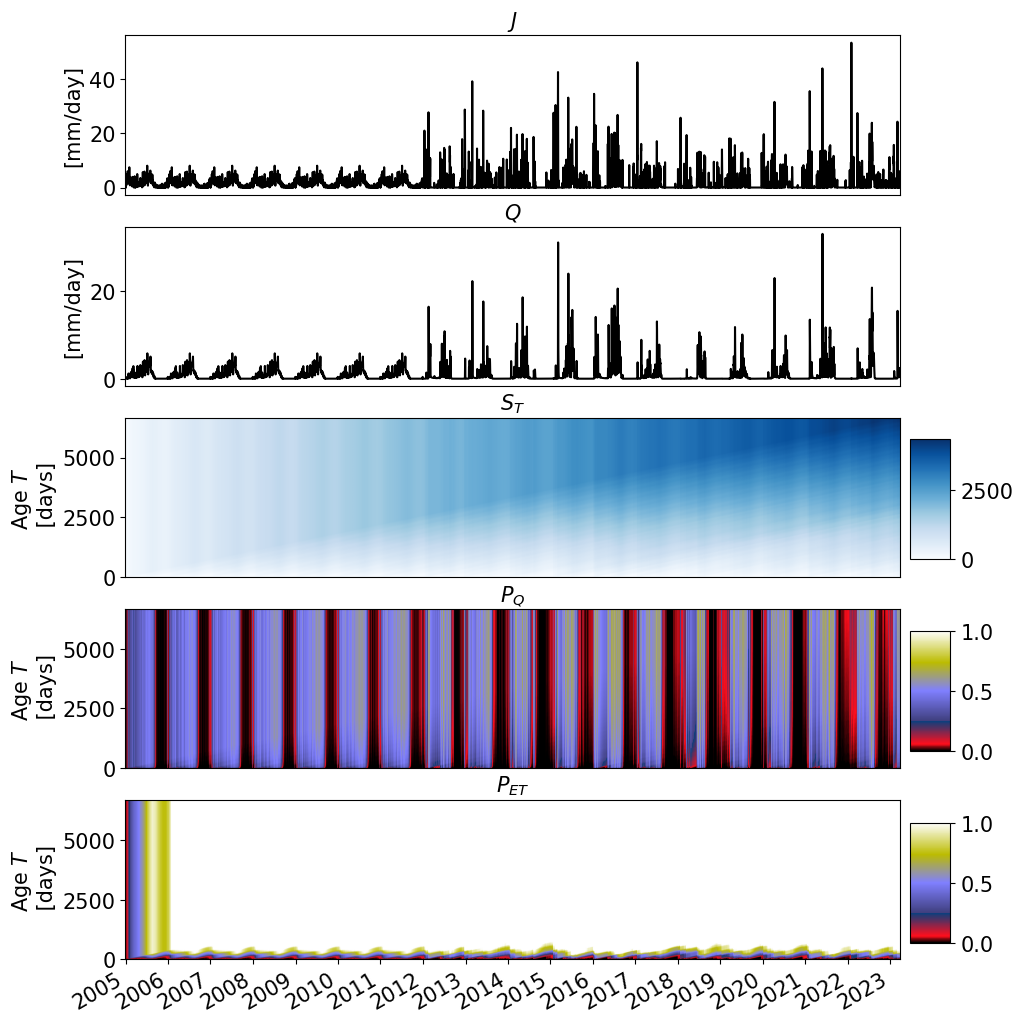

In [15]:
plot_PQET_ST(J, Q, sT, pQETs, dt, time, age_cut=8000);


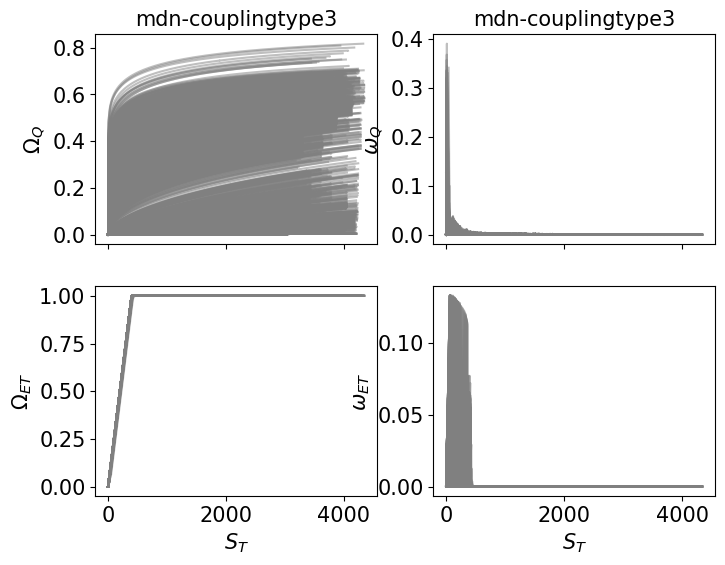

In [16]:
# Age distribution
axes = plot_PQET_ST2(sT, pQETs, dt, last_age_cut=2000, figsize=(8,6), label=model_name)


In [20]:
pQETs2 = jnp.maximum(pQETs, 0)

pQ = pQETs2[...,0]
pET = pQETs2[...,1]
PQ = jnp.cumsum(pQ, axis=0) * dt
PET = jnp.cumsum(pET, axis=0) * dt
ST = jnp.cumsum(sT[:,1:], axis=0) * dt
S = ST[-1,:]

ωQ = (PQ[1:,:] - PQ[:-1,:]) / (ST[1:,:] - ST[:-1,:])
ωET = (PET[1:,:] - PET[:-1,:]) / (ST[1:,:] - ST[:-1,:])
ωQ = jnp.nan_to_num(ωQ, nan=0.0, posinf=0.0, neginf=0.0)
ωET = jnp.nan_to_num(ωET, nan=0.0, posinf=0.0, neginf=0.0)

ωQ = jnp.maximum(ωQ, 0)
ωET = jnp.maximum(ωET, 0)

QT = jax.vmap(lambda a,b: a*b, in_axes=(0,1), out_axes=1)(Q, PQ)
ETT = jax.vmap(lambda a,b: a*b, in_axes=(0,1), out_axes=1)(ET, PQ)
ST_scaled = jax.vmap(lambda a,b: a/b, in_axes=(1,0), out_axes=1)(ST,S)

# Calculate the complement
STC = jax.vmap(lambda a,b: a-b, in_axes=(0,1), out_axes=1)(S, ST)
QTC = jax.vmap(lambda a,b: a-b, in_axes=(0,1), out_axes=1)(Q, QT)
ETTC = jax.vmap(lambda a,b: a-b, in_axes=(0,1), out_axes=1)(ET, ETT)

Qω = jax.vmap(lambda a,b: a*b, in_axes=(0,1), out_axes=1)(Q, ωQ)
ETω = jax.vmap(lambda a,b: a*b, in_axes=(0,1), out_axes=1)(ET, ωET)


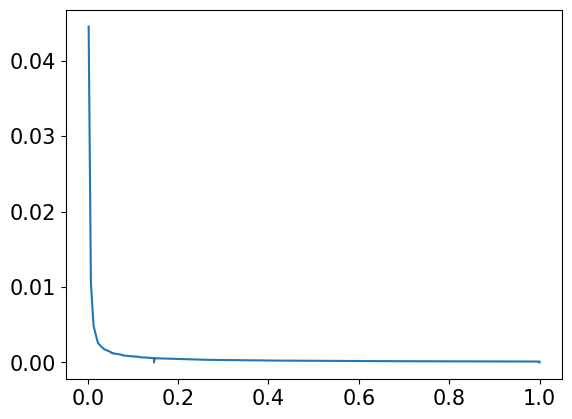

In [135]:
# plt.plot(STC[:,2666], QTC[:,2666])
plt.plot(ST_scaled[1:,100], Qω[:,100])

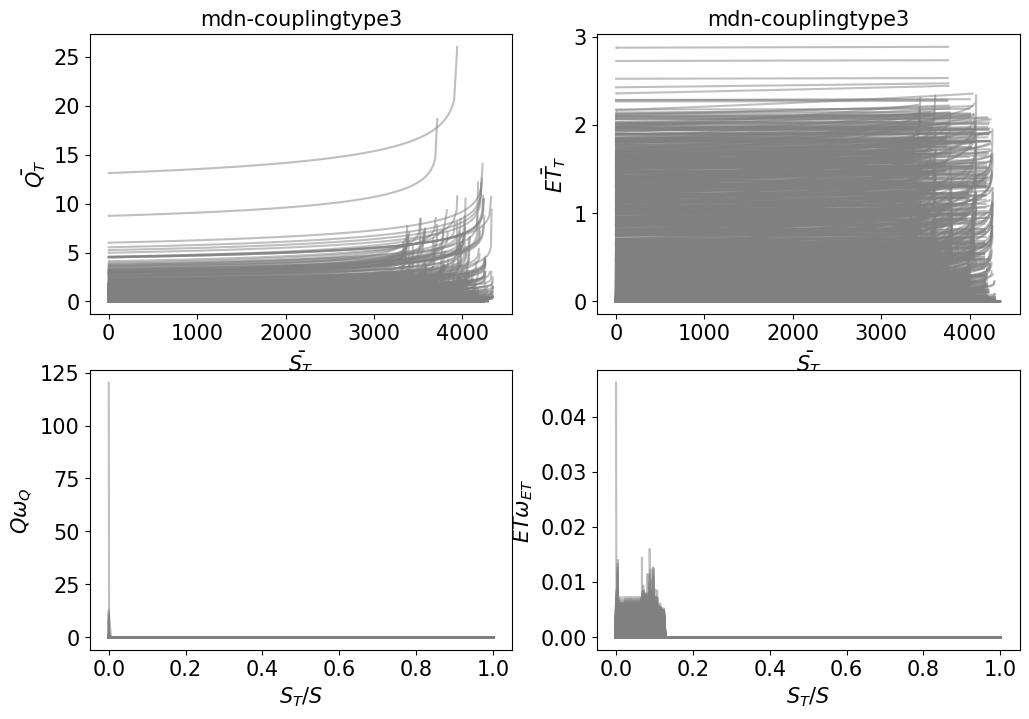

In [23]:
axes = plot_PQET_ST3(Q, ET, pQETs, sT, dt, last_age_cut=2000, figsize=(12,8), label=model_name)


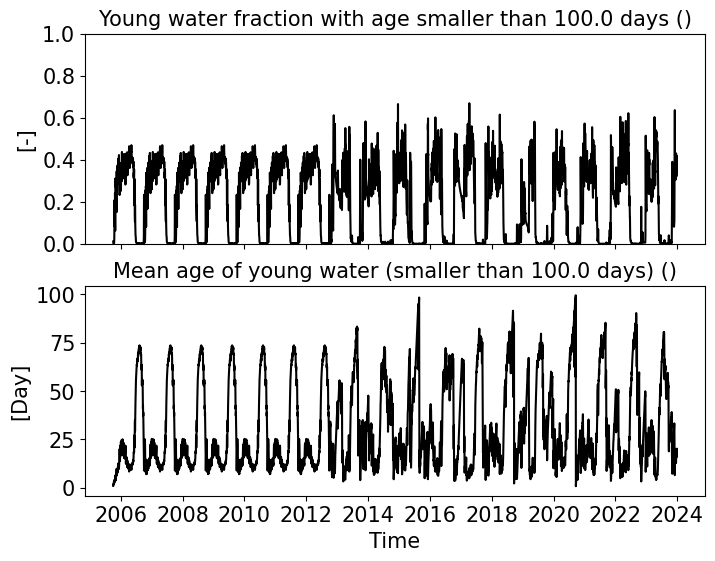

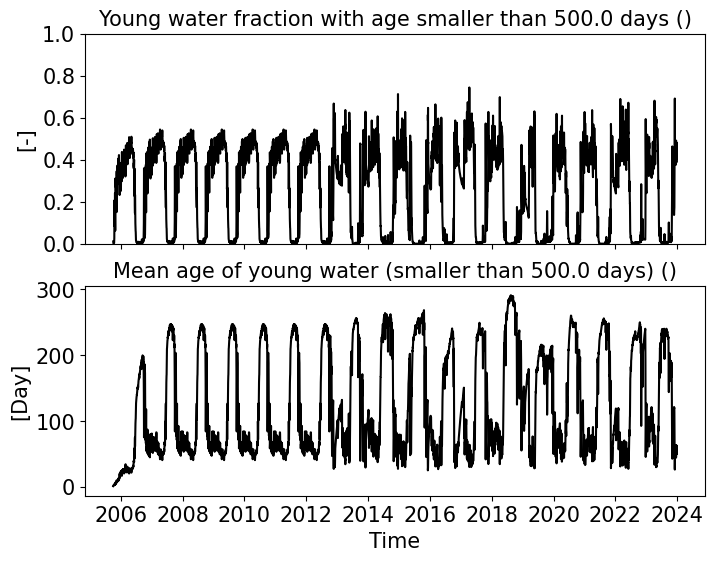

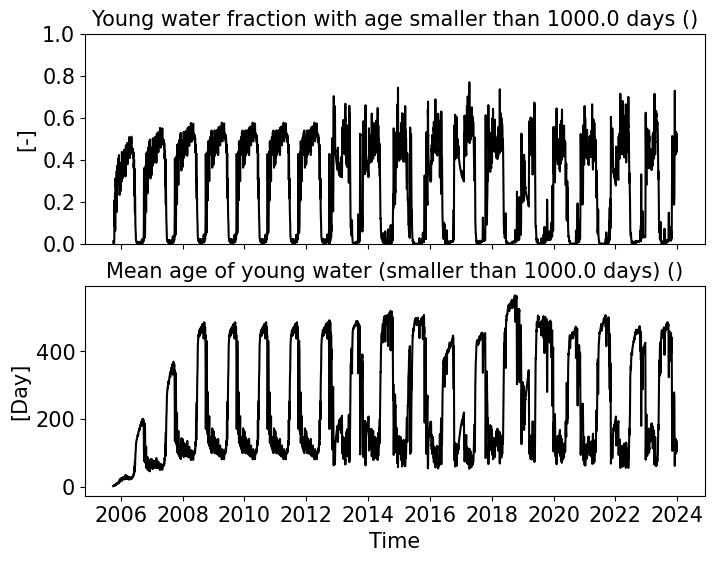

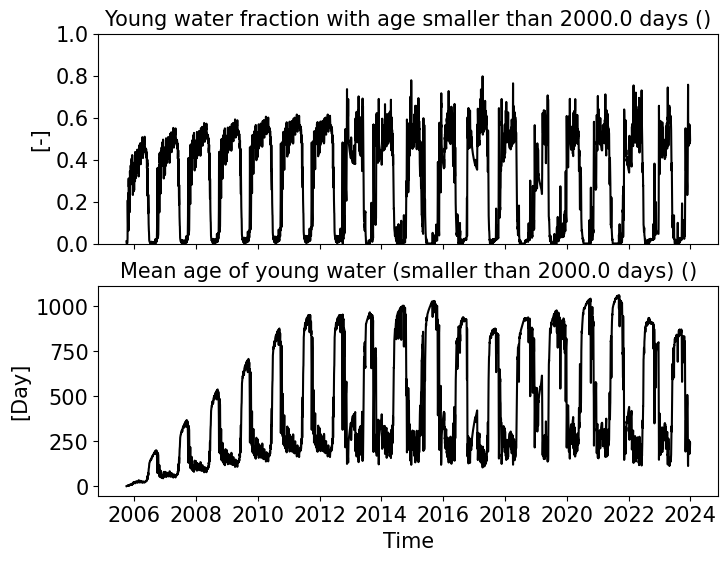

In [11]:
# Young water fraction in streamflow
for cutoff in [100,500,1000,2000]:
    axes = plot_young_water(pQETs[...,0], time, dt=dt, cutoff_age=cutoff)
    # axes[1].set(ylim=[0,1000]);


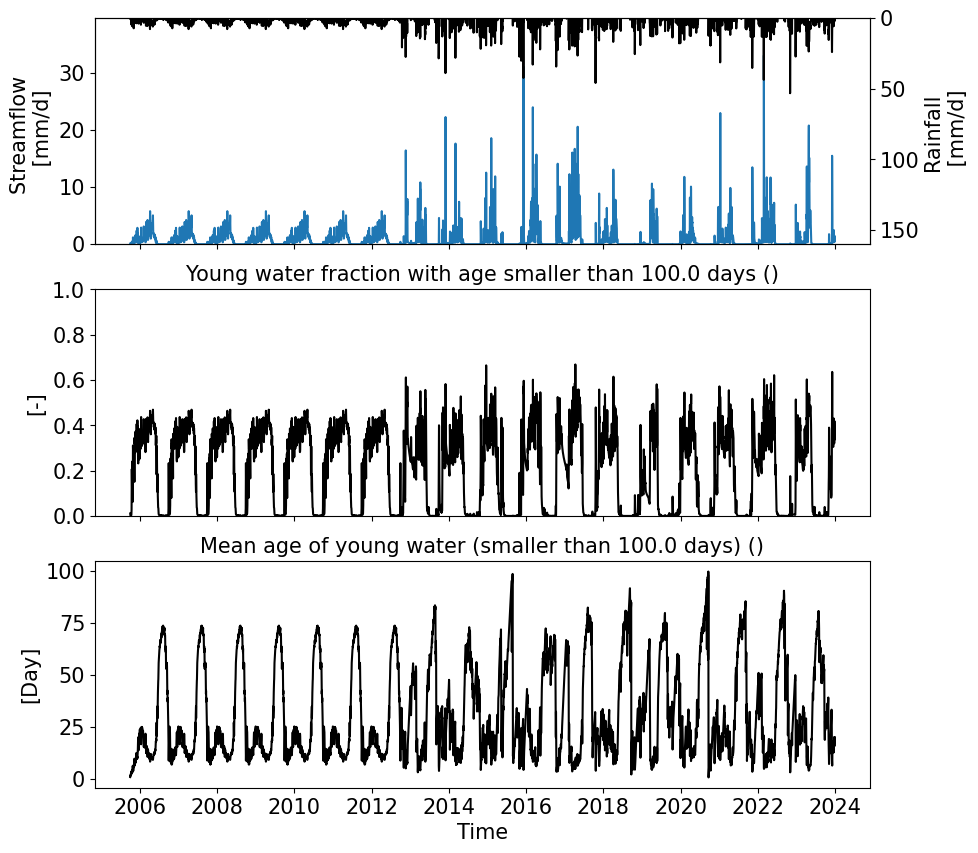

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(10,10), sharex=True)
plot_J_Q(J, Q, time, ax=axes[0])
axes = plot_young_water(pQETs[...,0], time, axes=axes[1:], dt=dt, cutoff_age=100);


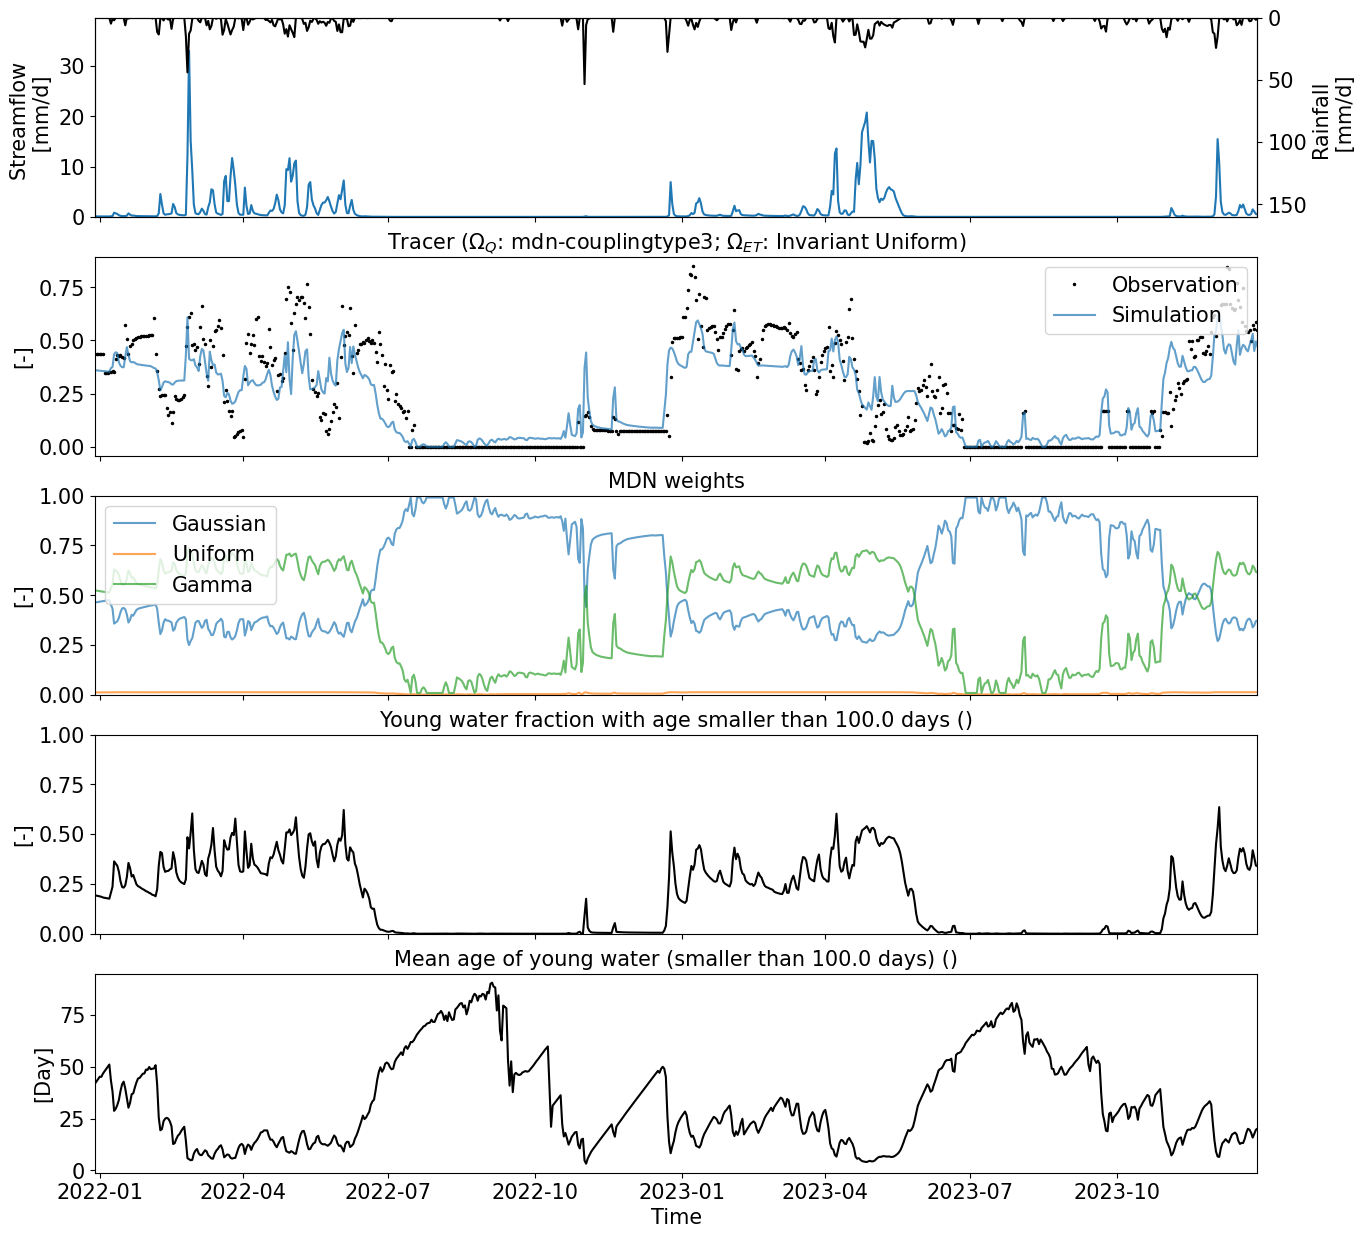

In [15]:
# MDN weights -- zoom in
cutoff=365*2
distributions = ['Gaussian', 'Uniform', 'Gamma']
fig, axes = plt.subplots(5, 1, figsize=(15,15), sharex=True)
plot_J_Q(J[-cutoff:], Q[-cutoff:], time[-cutoff:], ax=axes[0])
ax = plot_timeseries_obs_sim(
    obs=df.iloc[-cutoff:]['C_Q'].values, sim=df.iloc[-cutoff:]['C_Q_sim'].values, lim=[0,1], timesteps=df.iloc[-cutoff:].index,
    ax=axes[1], varn=f'Tracer ($\Omega_Q$: {model_name}; ' + '$\Omega_{ET}$: Invariant Uniform)'
)
ax.set(xlabel='')
for i,dist in enumerate(distributions):
    axes[2].plot(time[-cutoff:], mdn_w[-cutoff:,i], alpha=0.7, label=dist)
axes[2].set(title='MDN weights', ylabel='[-]', ylim=[0,1])
axes[2].legend()
plot_young_water(pQETs[:,-cutoff:,0], time[-cutoff:], dt=dt, axes=axes[-2:], cutoff_age=100);
